Accuracy: 0.8947368421052632

Confusion Matrix:
 [[37  6]
 [ 6 65]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.86      0.86        43
           1       0.92      0.92      0.92        71

    accuracy                           0.89       114
   macro avg       0.89      0.89      0.89       114
weighted avg       0.89      0.89      0.89       114


Feature Importances:
Feature 1: 0.6599
Feature 2: 0.3401


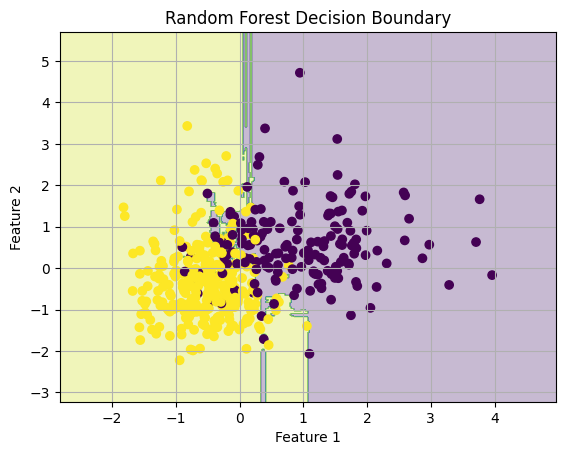


Random Forest model executed successfully.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# LOAD DATASET
data = load_breast_cancer()
X = data.data[:, :2]   # Use first 2 features for visualization
y = data.target

# TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# FEATURE SCALING
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# MODEL TRAINING
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# PREDICTION & EVALUATION
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Feature Importance
print("\nFeature Importances:")
for i, val in enumerate(model.feature_importances_):
    print(f"Feature {i+1}: {val:.4f}")

# ======================================
# DECISION BOUNDARY FUNCTION
# ======================================
def plot_boundary(X, y, model):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.02),
        np.arange(y_min, y_max, 0.02)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.title("Random Forest Decision Boundary")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.grid()
    plt.show()

# ======================================
# VISUALIZATION
# ======================================
plot_boundary(X_train, y_train, model)

# ======================================
# FINAL RESULT
# ======================================
print("\nRandom Forest model executed successfully.")